<div style="background:linear-gradient(135deg,#0d1220,#141829);border:2px solid #2EC4B6;border-radius:14px;padding:40px;text-align:center;font-family:serif;">
<div style="font-size:12px;letter-spacing:4px;color:#2EC4B6;text-transform:uppercase;margin-bottom:12px;">Patience Anono</div>
<h1 style="font-size:36px;font-weight:900;color:#F0F0F0;margin:0 0 8px;">Shopify Cohort Retention Analysis</h1>
<h2 style="font-size:20px;font-weight:300;color:#2EC4B6;margin:0 0 24px;">SQL Pipeline · Python Heatmaps · Revenue Intelligence</h2>
<hr style="border:1px solid #282878;margin:20px auto;width:60%;">
<p style="color:#8b95b0;font-size:13px;margin:4px 0;"><b style="color:#F0F0F0;">Analyst:</b> Patience Anono — PA Data Analytics</p>
<p style="color:#8b95b0;font-size:13px;margin:4px 0;"><b style="color:#F0F0F0;">Industry:</b> E-Commerce · Shopify</p>
<p style="color:#8b95b0;font-size:13px;margin:4px 0;"><b style="color:#F0F0F0;">Dataset:</b> 6,404 orders · 2,810 customers · Oct 2023 – Dec 2024</p>
<p style="color:#8b95b0;font-size:13px;margin:4px 0;"><b style="color:#F0F0F0;">Tools:</b> Python · SQL (SQLite) · Pandas · Seaborn · Matplotlib</p>
</div>

---
## Section 1  Business Context & Problem Statement

### The Business Situation

An e-commerce brand on Shopify is generating steady transaction volume but leadership cannot answer a fundamental question clearly: **are customers coming back and if not, when exactly are they leaving?**

The current view of the business is revenue-focused — total sales, average order value, best-selling products. Those numbers look acceptable. What nobody has looked at is the *cohort view* — tracking groups of customers over time and measuring what percentage of each group returns to purchase in subsequent months.

Without that view, several critical things are invisible:
- Whether customer retention is improving or declining over time
- Which acquisition months produced the most loyal customers
- Whether revenue growth is driven by new customers, returning customers or both
- The revenue impact of losing customers in month 1 versus month 6
---

### The Four Questions We Are Answering

| Question | Where it is answered |
|---|---|
| When do customers stop returning? | Retention heatmap — Section 8 |
| How does retention vary by acquisition month? | Cohort curves — Section 9 |
| Which cohorts generate the most long-term revenue? | Revenue heatmap + cumulative chart — Sections 10 & 12 |
| What should the business do about it? | Recommendations — Section 15 |

---

### Why Cohort Analysis Specifically?

Standard aggregate metrics hide what cohort analysis reveals. If total monthly revenue is stable or growing, things look fine. But that stability might be masking a situation where each new cohort retains worse than the previous one — offset by higher acquisition volume. Cohort analysis strips that mask away.

A business with 30% M1 retention and growing acquisition looks identical in aggregate revenue to a business with 50% M1 retention and flat acquisition. Their long-term trajectories are completely different.

> **Star metric: M1 Retention Rate** — the percentage of customers who return to purchase in the month after their first order. This single number is the most predictive indicator of long-term customer value in e-commerce.

---
## Section 2  Data Source & Structure

### About This Dataset

This analysis uses a **Shopify-format orders dataset**  (Orders > Export All > CSV). The dataset covers 15 months from October 2023 through December 2024.

---

### Column Reference

| Column | Type | Description |
|---|---|---|
| `order_id` | string | Unique order identifier |
| `customer_id` | string | Unique customer identifier |
| `created_at` | datetime | Order timestamp — primary date field |
| `financial_status` | string | `paid`, `refunded`, etc. |
| `total_price` | float | Final order total — primary revenue metric |
| `product_category` | string | Clothing, Electronics, Beauty, Home, Sports |
| `billing_country` | string | Customer country |
| `source_name` | string | Acquisition channel: google, facebook, email, organic |

---

### How Cohort Analysis Works

**Cohort** = a group of customers defined by the month they made their first purchase.

- All customers who first bought in October 2023 → the *Oct-2023 cohort*
- All customers who first bought in November 2023 → the *Nov-2023 cohort*

**Cohort Index** = months after first purchase we are measuring.
- Month 0 = the acquisition month (always 100% by definition)
- Month 1 = one calendar month after first purchase
- Month 6 = six months after first purchase

**Retention Rate** = (customers who purchased in month N) / (total cohort size at month 0) × 100

The result is a matrix. That matrix becomes the heatmap.

---
## Section 3  Imports the necessary libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# brand palette
BG      = '#0d1220'
DARK    = '#141829'
NAVY    = '#282878'
BLUE    = '#3C78C8'
TEAL    = '#2EC4B6'
ORANGE  = '#FF9F1C'
WHITE   = '#F0F0F0'
GREY    = '#8b95b0'
LTGREY  = '#1a1f35'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': DARK,
    'axes.edgecolor':   GREY, 'axes.labelcolor': WHITE,
    'axes.titlecolor':  WHITE,'axes.titlesize':  13,
    'axes.labelsize':   11,   'xtick.color': GREY,
    'ytick.color':      GREY, 'text.color':  WHITE,
    'grid.color':       LTGREY, 'grid.linestyle': '--', 'grid.alpha': 0.4,
    'legend.facecolor': DARK, 'legend.edgecolor': GREY,
    'font.family':      'DejaVu Sans', 'figure.dpi': 130,
})

# Custom colourmaps
cm_teal   = LinearSegmentedColormap.from_list('pa_teal',
    ['#0d1220','#1a3a5c','#1A7A70','#2EC4B6','#7de8df','#c8f7f4'])
cm_orange = LinearSegmentedColormap.from_list('pa_orange',
    ['#0d1220','#1a2040','#2a3060','#B05000','#e87000','#FF9F1C','#ffd580'])

# Output directories
BASE    = Path('..')
VISUALS = BASE / 'visuals'; VISUALS.mkdir(exist_ok=True)
DATA_P  = BASE / 'data' / 'processed'; DATA_P.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    p = VISUALS / name
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f'  Saved: {p.name}')

print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
print(f'seaborn {sns.__version__}')
print('Environment ready.')

pandas  1.4.2
numpy   1.21.5
seaborn 0.11.2
Environment ready.


---
## Section 4 Data Loading & Validation

We load the Shopify orders CSV and run a full quality check.

In [2]:
df = pd.read_csv(BASE / 'data' / 'raw' / 'shopify_orders.csv', parse_dates=['created_at'])

print(f'Rows (orders)      : {len(df):,}')
print(f'Unique customers   : {df["customer_id"].nunique():,}')
print(f'Columns            : {df.shape[1]}')
print(f'Date range         : {df["created_at"].min().date()}  to  {df["created_at"].max().date()}')
print(f'Total revenue      : ${df["total_price"].sum():,.2f}')
print(f'Avg order value    : ${df["total_price"].mean():.2f}')
print(f'Median order value : ${df["total_price"].median():.2f}')

Rows (orders)      : 6,404
Unique customers   : 2,810
Columns            : 20
Date range         : 2023-10-01  to  2024-12-26
Total revenue      : $401,672.09
Avg order value    : $62.72
Median order value : $53.78


In [3]:
df.head()

,order_id,customer_id,email,first_name,created_at,financial_status,fulfillment_status,currency,subtotal_price,total_discounts,total_shipping_price,total_price,product_title,product_category,billing_city,billing_country,billing_country_code,source_name,source_medium,tags
0,#7077,CUST02709,customer2709@example.com,Customer2709,2023-10-01,paid,fulfilled,USD,26.34,3.95,0.00,22.39,Resistance Band Set,Sports & Fitness,London,United Kingdom,GB,organic,organic,NaN
1,#4391,CUST01517,customer1517@example.com,Customer1517,2023-10-01,paid,unfulfilled,USD,57.97,0.00,9.99,67.96,Face Serum Vitamin C,Beauty & Skincare,Dubai,United Arab Emirates,AE,google,cpc,NaN
2,#5430,CUST01980,customer1980@example.com,Customer1980,2023-10-01,paid,fulfilled,USD,49.21,7.38,6.99,48.82,Face Serum Vitamin C,Beauty & Skincare,Johannesburg,South Africa,ZA,facebook,cpc,NaN
3,#2392,CUST00615,customer615@example.com,Customer615,2023-10-01,paid,fulfilled,USD,25.02,0.00,9.99,35.01,Lip Balm Set,Beauty & Skincare,Nairobi,Kenya,KE,direct,none,NaN
4,#2893,CUST00837,customer837@example.com,Customer837,2023-10-01,paid,fulfilled,USD,25.62,0.00,0.00,25.62,Scented Soy Candle,Home & Living,Johannesburg,South Africa,ZA,google,cpc,NaN


In [4]:
# Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
has_missing = audit[audit['Missing'] > 0]

if has_missing.empty:
    print('No missing values in any column.')
else:
    print(has_missing.to_string())

print(f'\nDuplicate rows     : {df.duplicated().sum()}')
print(f'Negative revenue   : {(df["total_price"] < 0).sum()}')
print(f'Zero revenue       : {(df["total_price"] == 0).sum()}')

      Missing    Pct
tags     6404  100.0

Duplicate rows     : 0
Negative revenue   : 0
Zero revenue       : 0


In [5]:
# Financial and fulfillment status breakdown
print("Financial status:")
print(df['financial_status'].value_counts().to_string())
print("\nAcquisition channels:")
print(df['source_name'].value_counts().to_string())
print("\nProduct categories:")
print(df['product_category'].value_counts().to_string())

Financial status:
paid    6404

Acquisition channels:
google       1346
organic      1322
facebook     1085
instagram    1016
direct        681
email         596
tiktok        358

Product categories:
Electronics           1321
Clothing & Apparel    1310
Home & Living         1273
Sports & Fitness      1261
Beauty & Skincare     1239


In [6]:
# Prepare for SQL — SQLite stores dates as strings
df['order_date']  = df['created_at'].dt.strftime('%Y-%m-%d %H:%M:%S')
df['order_month'] = df['created_at'].dt.to_period('M').astype(str)

# Keep only paid orders
df_clean = df[df['financial_status'] == 'paid'].copy()
print(f'Orders after filtering to paid: {len(df_clean):,}')
print(f'Revenue after filter          : ${df_clean["total_price"].sum():,.2f}')

Orders after filtering to paid: 6,404
Revenue after filter          : $401,672.09


---
## Section 5  Exploratory Data Analysis

Before building the cohort model, we understand the data's shape — monthly trends, channel mix, category performance. 

  Saved: 0_monthly_overview.png


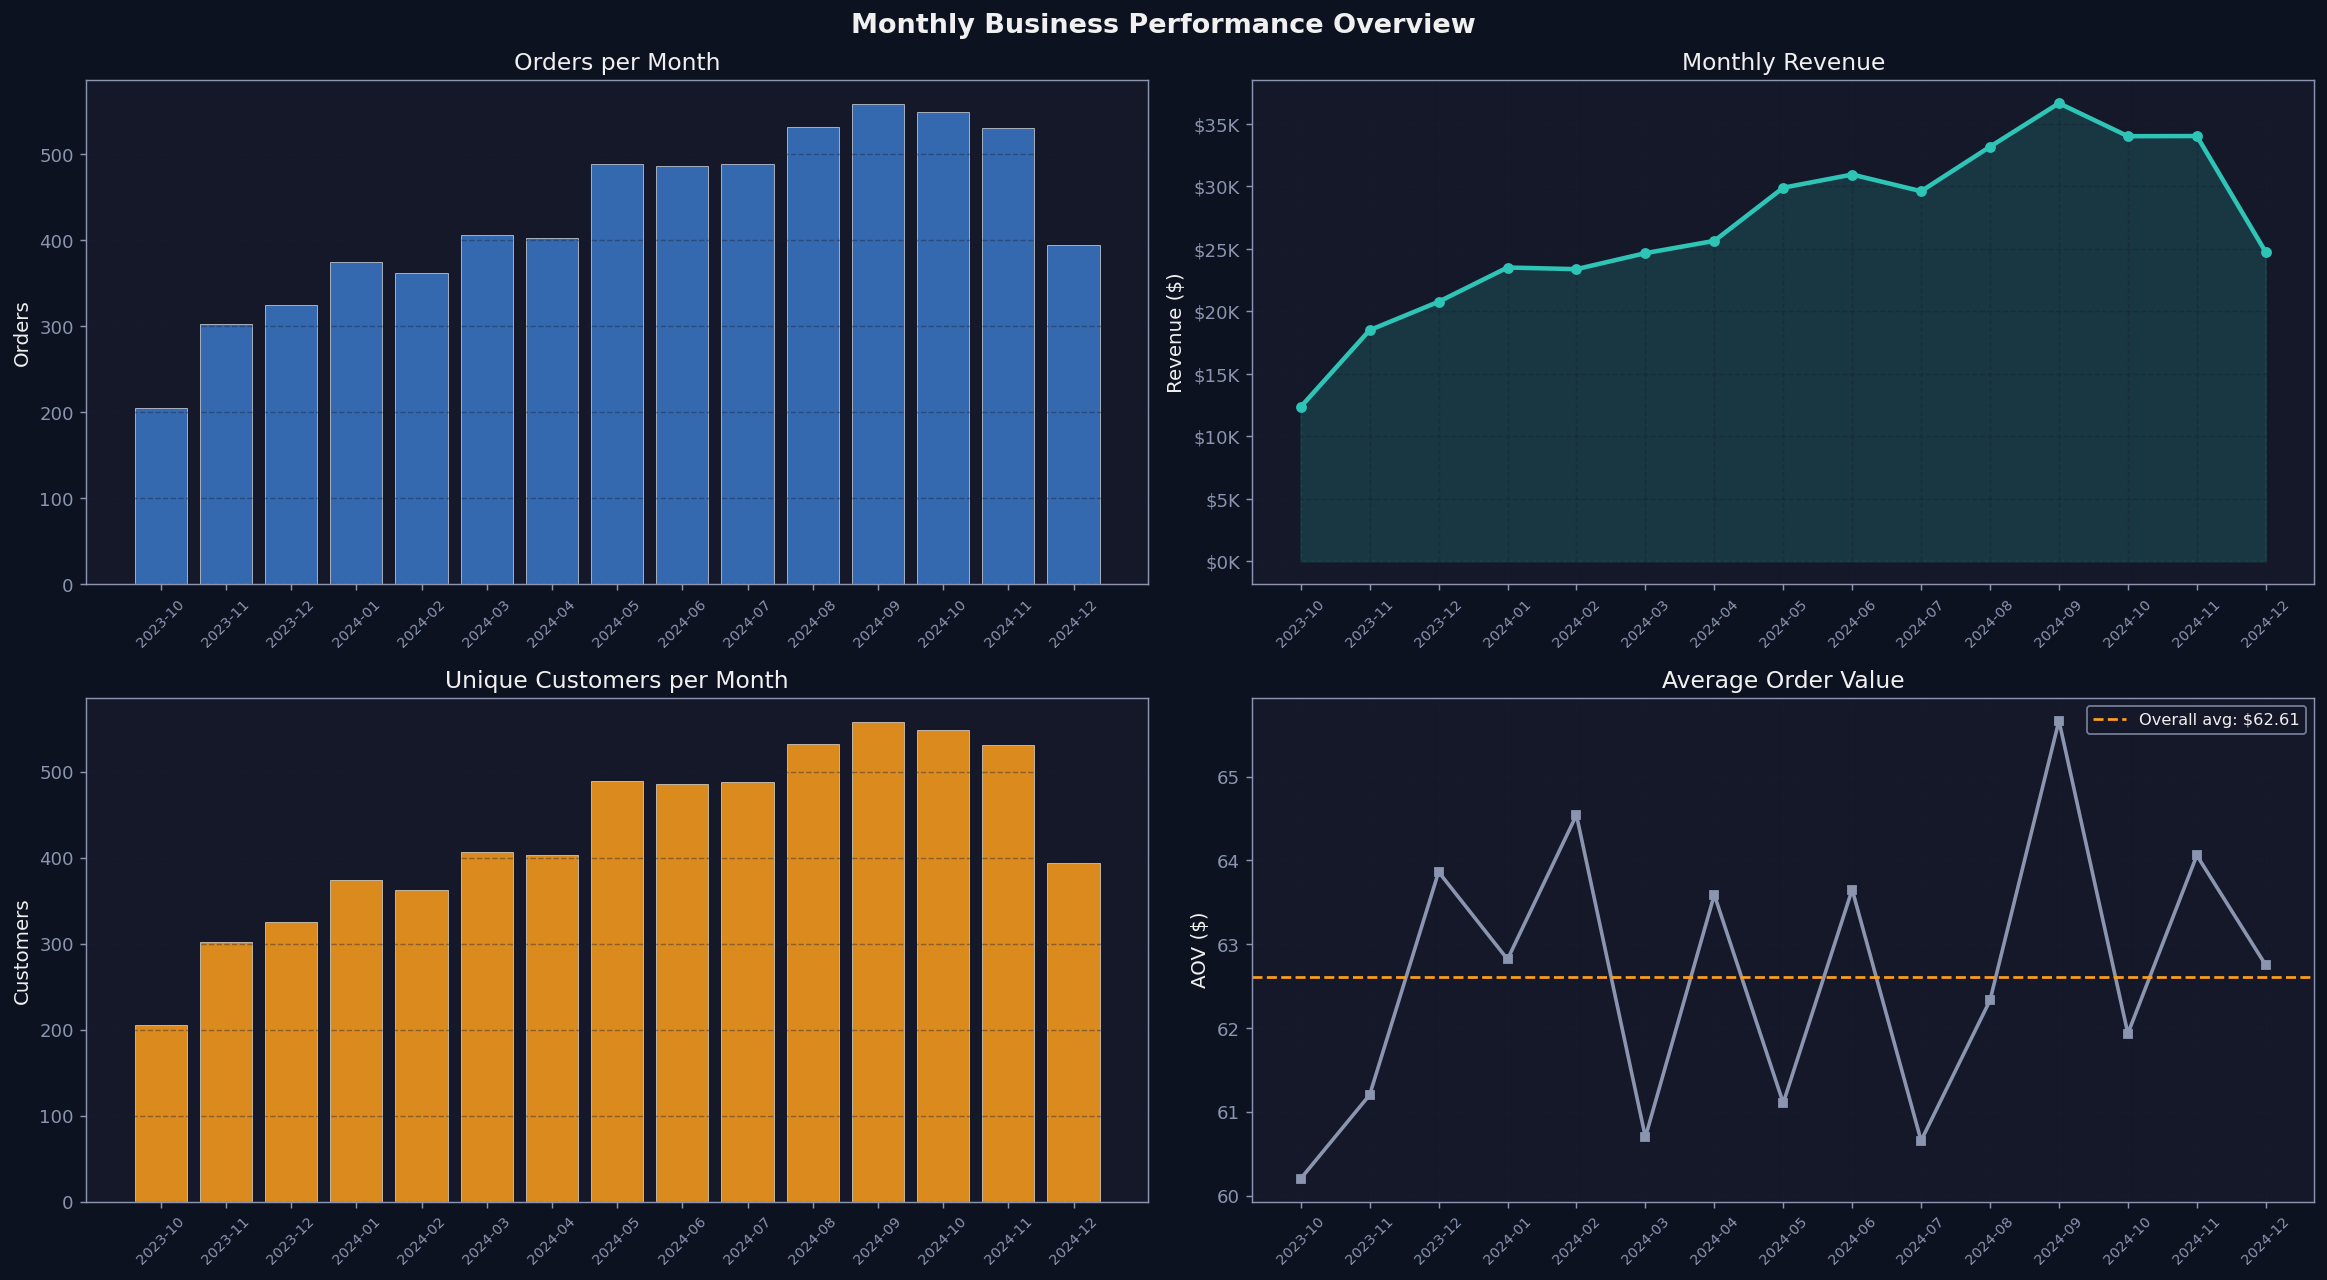

In [7]:
monthly = df_clean.groupby('order_month').agg(
    orders    = ('order_id', 'count'),
    customers = ('customer_id', 'nunique'),
    revenue   = ('total_price', 'sum'),
    aov       = ('total_price', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Monthly Business Performance Overview', fontsize=15, fontweight='bold', color=WHITE)

axes[0,0].bar(monthly['order_month'], monthly['orders'], color=BLUE, edgecolor=WHITE, linewidth=0.4, alpha=0.85)
axes[0,0].set_title('Orders per Month'); axes[0,0].set_ylabel('Orders')
axes[0,0].tick_params(axis='x', rotation=45, labelsize=8); axes[0,0].grid(axis='y')

axes[0,1].fill_between(monthly['order_month'], monthly['revenue'], alpha=0.18, color=TEAL)
axes[0,1].plot(monthly['order_month'], monthly['revenue'], color=TEAL, linewidth=2.5, marker='o', markersize=5)
axes[0,1].set_title('Monthly Revenue'); axes[0,1].set_ylabel('Revenue ($)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0,1].tick_params(axis='x', rotation=45, labelsize=8); axes[0,1].grid(True)

axes[1,0].bar(monthly['order_month'], monthly['customers'], color=ORANGE, edgecolor=WHITE, linewidth=0.4, alpha=0.85)
axes[1,0].set_title('Unique Customers per Month'); axes[1,0].set_ylabel('Customers')
axes[1,0].tick_params(axis='x', rotation=45, labelsize=8); axes[1,0].grid(axis='y')

axes[1,1].plot(monthly['order_month'], monthly['aov'], color=GREY, linewidth=2, marker='s', markersize=4)
axes[1,1].axhline(monthly['aov'].mean(), color=ORANGE, linestyle='--', linewidth=1.5,
    label=f'Overall avg: ${monthly["aov"].mean():.2f}')
axes[1,1].set_title('Average Order Value'); axes[1,1].set_ylabel('AOV ($)')
axes[1,1].legend(fontsize=9); axes[1,1].tick_params(axis='x', rotation=45, labelsize=8); axes[1,1].grid(True)

plt.tight_layout()
save(fig, '0_monthly_overview.png')
plt.show()

  Saved: 0b_channel_category.png


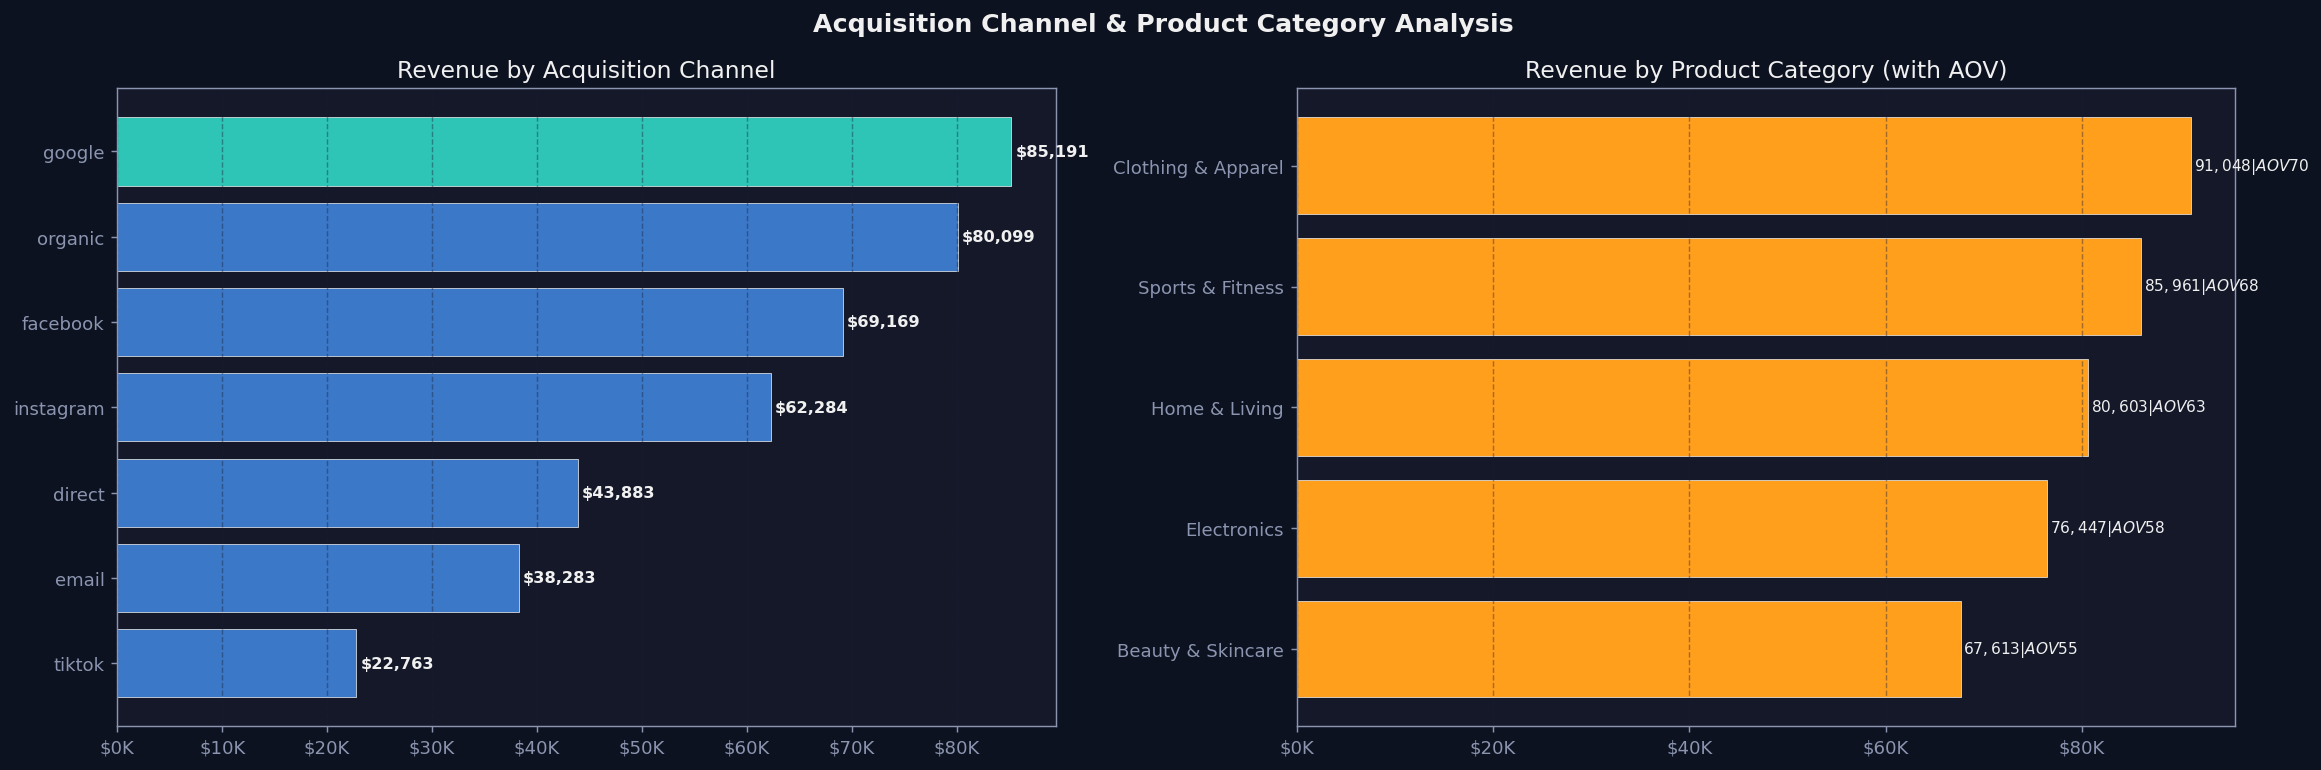

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Acquisition Channel & Product Category Analysis', fontsize=14, fontweight='bold', color=WHITE)

ch_rev = df_clean.groupby('source_name')['total_price'].sum().sort_values()
colors_ch = [TEAL if i == len(ch_rev)-1 else BLUE for i in range(len(ch_rev))]
bars = axes[0].barh(ch_rev.index, ch_rev.values, color=colors_ch, edgecolor=WHITE, linewidth=0.4)
for bar, val in zip(bars, ch_rev.values):
    axes[0].text(val+400, bar.get_y()+bar.get_height()/2, f'${val:,.0f}',
        va='center', color=WHITE, fontsize=9, fontweight='bold')
axes[0].set_title('Revenue by Acquisition Channel')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].grid(axis='x')

cat_rev = df_clean.groupby('product_category').agg(revenue=('total_price','sum'),aov=('total_price','mean')).sort_values('revenue')
bars2 = axes[1].barh(cat_rev.index, cat_rev['revenue'], color=ORANGE, edgecolor=WHITE, linewidth=0.4)
for bar, (idx, row) in zip(bars2, cat_rev.iterrows()):
    axes[1].text(row['revenue']+300, bar.get_y()+bar.get_height()/2,
        f'${row["revenue"]:,.0f}  |  AOV ${row["aov"]:.0f}', va='center', color=WHITE, fontsize=8.5)
axes[1].set_title('Revenue by Product Category (with AOV)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].grid(axis='x')

plt.tight_layout()
save(fig, '0b_channel_category.png')
plt.show()

---
## Section 6  SQL Cohort Pipeline

This is the technical centrepiece of the project. The entire cohort table is built using SQL — not pandas — because in a real production environment this query lives in BigQuery, Snowflake or your data warehouse and runs automatically on fresh data daily.

### Why SQL instead of pure pandas?

Two reasons:

1. **Portability** — this SQL (with minor dialect changes) runs in any SQL database. A data engineer can schedule it as a recurring pipeline in 20 minutes.
2. **Scalability** — at 500,000 or 5 million orders, pandas cohort calculations become slow. SQL scales without code changes.

---

### The Pipeline: 5 SQL Views

**View 1 — Cohort assignment:** Find each customer's first purchase date and extract the cohort month.

```sql
SELECT customer_id, MIN(order_date) AS first_order_date,
       SUBSTR(MIN(order_date), 1, 7) AS cohort_month
FROM orders GROUP BY customer_id
```

**View 2 — Cohort index:** For every order, calculate how many months after first purchase it was.

```sql
(year_diff * 12) + month_diff AS cohort_index
```

**View 3 — Active customers:** Count distinct customers per cohort × month combination.

**View 4 — Cohort sizes:** Count total customers per cohort at Month 0 (the denominator).

**Final query — Retention rates:** Divide active by total, multiply by 100.

In [9]:
# Load data into SQLite in-memory database
conn = sqlite3.connect(':memory:')
df_clean.to_sql('orders', conn, index=False, if_exists='replace')
print(f'Loaded {len(df_clean):,} rows into SQLite')

# VIEW 1: Customer cohort assignment
conn.execute("""
CREATE VIEW v_first_orders AS
SELECT
    customer_id,
    MIN(order_date)               AS first_order_date,
    SUBSTR(MIN(order_date), 1, 7) AS cohort_month
FROM orders
GROUP BY customer_id
""")
print(f'Cohorts created: {pd.read_sql("SELECT COUNT(DISTINCT cohort_month) AS n FROM v_first_orders", conn).iloc[0,0]}')
print(pd.read_sql("SELECT * FROM v_first_orders LIMIT 5", conn).to_string(index=False))

Loaded 6,404 rows into SQLite
Cohorts created: 15
customer_id    first_order_date cohort_month
  CUST00001 2024-08-23 00:00:00      2024-08
  CUST00002 2024-08-12 00:00:00      2024-08
  CUST00003 2024-04-20 00:00:00      2024-04
  CUST00004 2024-04-03 00:00:00      2024-04
  CUST00005 2024-02-02 00:00:00      2024-02


In [10]:
# VIEW 2: Cohort index (months since first purchase)
conn.execute("""
CREATE VIEW v_cohort_activity AS
SELECT
    o.customer_id,
    f.cohort_month,
    SUBSTR(o.order_date, 1, 7) AS order_month,
    (
        (CAST(SUBSTR(o.order_date,       1, 4) AS INTEGER) -
         CAST(SUBSTR(f.first_order_date, 1, 4) AS INTEGER)) * 12
        +
        (CAST(SUBSTR(o.order_date,       6, 2) AS INTEGER) -
         CAST(SUBSTR(f.first_order_date, 6, 2) AS INTEGER))
    ) AS cohort_index
FROM orders o
JOIN v_first_orders f ON o.customer_id = f.customer_id
""")

# Preview: one customer's activity across months
sample_cust = pd.read_sql("SELECT customer_id FROM v_first_orders LIMIT 1", conn).iloc[0,0]
print(f"Activity for customer {sample_cust}:")
print(pd.read_sql(f"SELECT * FROM v_cohort_activity WHERE customer_id = '{sample_cust}'", conn).to_string(index=False))

Activity for customer CUST00001:
customer_id cohort_month order_month  cohort_index
  CUST00001      2024-08     2024-08             0
  CUST00001      2024-08     2024-09             1
  CUST00001      2024-08     2024-11             3


In [11]:
# VIEWS 3 & 4: Count active customers and cohort sizes
conn.execute("""
CREATE VIEW v_cohort_size AS
SELECT cohort_month, cohort_index, COUNT(DISTINCT customer_id) AS active_customers
FROM v_cohort_activity
GROUP BY cohort_month, cohort_index
""")

conn.execute("""
CREATE VIEW v_cohort_totals AS
SELECT cohort_month, COUNT(DISTINCT customer_id) AS cohort_size
FROM v_first_orders
GROUP BY cohort_month
""")

# FINAL QUERY: Retention rates
retention_df = pd.read_sql("""
SELECT
    s.cohort_month,
    t.cohort_size,
    s.cohort_index,
    s.active_customers,
    ROUND(
        CAST(s.active_customers AS FLOAT) /
        CAST(t.cohort_size AS FLOAT) * 100, 1
    ) AS retention_rate_pct
FROM v_cohort_size s
JOIN v_cohort_totals t ON s.cohort_month = t.cohort_month
ORDER BY s.cohort_month, s.cohort_index
""", conn)

print(f'Retention table: {len(retention_df):,} rows')
print(f'Cohort months  : {retention_df["cohort_month"].nunique()}')
print(f'Max index      : {retention_df["cohort_index"].max()} months')
print()
print('Oct-2023 cohort retention:')
print(retention_df[retention_df['cohort_month']=='2023-10'].to_string(index=False))

Retention table: 120 rows
Cohort months  : 15
Max index      : 14 months

Oct-2023 cohort retention:
cohort_month  cohort_size  cohort_index  active_customers  retention_rate_pct
     2023-10          205             0               205               100.0
     2023-10          205             1                80                39.0
     2023-10          205             2                47                22.9
     2023-10          205             3                38                18.5
     2023-10          205             4                35                17.1
     2023-10          205             5                31                15.1
     2023-10          205             6                21                10.2
     2023-10          205             7                30                14.6
     2023-10          205             8                22                10.7
     2023-10          205             9                25                12.2
     2023-10          205            10  

In [12]:
# Bonus SQL: Revenue metrics per cohort
revenue_by_cohort = pd.read_sql("""
SELECT f.cohort_month,
       COUNT(DISTINCT o.customer_id)                              AS customers,
       COUNT(o.order_id)                                          AS orders,
       ROUND(SUM(o.total_price), 2)                               AS total_revenue,
       ROUND(SUM(o.total_price) / COUNT(DISTINCT o.customer_id), 2) AS rev_per_customer,
       ROUND(AVG(o.total_price), 2)                               AS aov
FROM orders o
JOIN v_first_orders f ON o.customer_id = f.customer_id
GROUP BY f.cohort_month
ORDER BY f.cohort_month
""", conn)

# Revenue per customer per cohort index
rev_detail = pd.read_sql("""
SELECT f.cohort_month, ca.cohort_index,
       ROUND(SUM(o.total_price), 2)                               AS revenue,
       COUNT(DISTINCT o.customer_id)                              AS customers,
       ROUND(SUM(o.total_price)/COUNT(DISTINCT o.customer_id), 2) AS rev_per_cust
FROM orders o
JOIN v_first_orders f  ON o.customer_id = f.customer_id
JOIN v_cohort_activity ca
    ON o.customer_id = ca.customer_id
    AND SUBSTR(o.order_date, 1, 7) = ca.order_month
WHERE ca.cohort_index <= 14
GROUP BY f.cohort_month, ca.cohort_index
ORDER BY f.cohort_month, ca.cohort_index
""", conn)

channel_summary = pd.read_sql("""
SELECT o.source_name AS channel,
       COUNT(DISTINCT o.customer_id) AS customers,
       ROUND(AVG(o.total_price), 2)  AS aov,
       ROUND(SUM(o.total_price), 2)  AS total_revenue
FROM orders o
JOIN v_first_orders f ON o.customer_id = f.customer_id
GROUP BY o.source_name
ORDER BY total_revenue DESC
""", conn)

conn.close()
print('All SQL queries complete.')

All SQL queries complete.


---
## Section 7 Building the Cohort Pivot Tables

SQL gives us a long-format table (one row per cohort × month). For heatmaps we pivot into a matrix — cohort months as rows, cohort indices as columns, retention rates as values.

We filter out cohorts with fewer than 30 customers — too small to draw reliable conclusions.

In [13]:
# Filter and pivot retention rates
ret_f = retention_df[
    (retention_df['cohort_index'] <= 14) &
    (retention_df['cohort_month'] >= '2023-10')
].copy()

pivot_retention = ret_f.pivot_table(
    index='cohort_month', columns='cohort_index',
    values='retention_rate_pct', aggfunc='mean')

# Remove small cohorts
cohort_sizes   = pivot_retention[0]
pivot_retention = pivot_retention[cohort_sizes >= 30]
cohort_sizes    = cohort_sizes[cohort_sizes >= 30]

# Revenue pivots
pivot_revenue = rev_detail.pivot_table(
    index='cohort_month', columns='cohort_index',
    values='rev_per_cust', aggfunc='mean')
pivot_revenue = pivot_revenue[pivot_revenue.index.isin(pivot_retention.index)]

pivot_rev_total = rev_detail.pivot_table(
    index='cohort_month', columns='cohort_index',
    values='revenue', aggfunc='sum')
pivot_rev_total = pivot_rev_total[pivot_rev_total.index.isin(pivot_retention.index)]

print(f'Pivot shape: {pivot_retention.shape}  (cohorts x months)')
print()
print('Cohort sizes:')
for month, size in cohort_sizes.items():
    bar = chr(9608) * int(size / 14)
    print(f'  {month}  {int(size):>4}  {bar}')

Pivot shape: (15, 15)  (cohorts x months)

Cohort sizes:
  2023-10   100  ███████
  2023-11   100  ███████
  2023-12   100  ███████
  2024-01   100  ███████
  2024-02   100  ███████
  2024-03   100  ███████
  2024-04   100  ███████
  2024-05   100  ███████
  2024-06   100  ███████
  2024-07   100  ███████
  2024-08   100  ███████
  2024-09   100  ███████
  2024-10   100  ███████
  2024-11   100  ███████
  2024-12   100  ███████


---
## Section 8  Main Retention Heatmap

This is the primary deliverable. Each row = an acquisition cohort. Each column = months after acquisition. Each cell = what % of the original cohort was still purchasing that month.

**How to read it:**
- The empty diagonal in the bottom-right is **not missing data** — it is the future. Recent cohorts have not had time to generate later-month data yet.
- Darker = lower retention. Lighter teal = higher retention.
- **Month 0 (orange border)** is always 100% — everyone is in the cohort at acquisition by definition.
- **The most important column is M1.** The drop from M0 to M1 is where most customers leave.

  Saved: 1_cohort_retention_heatmap.png


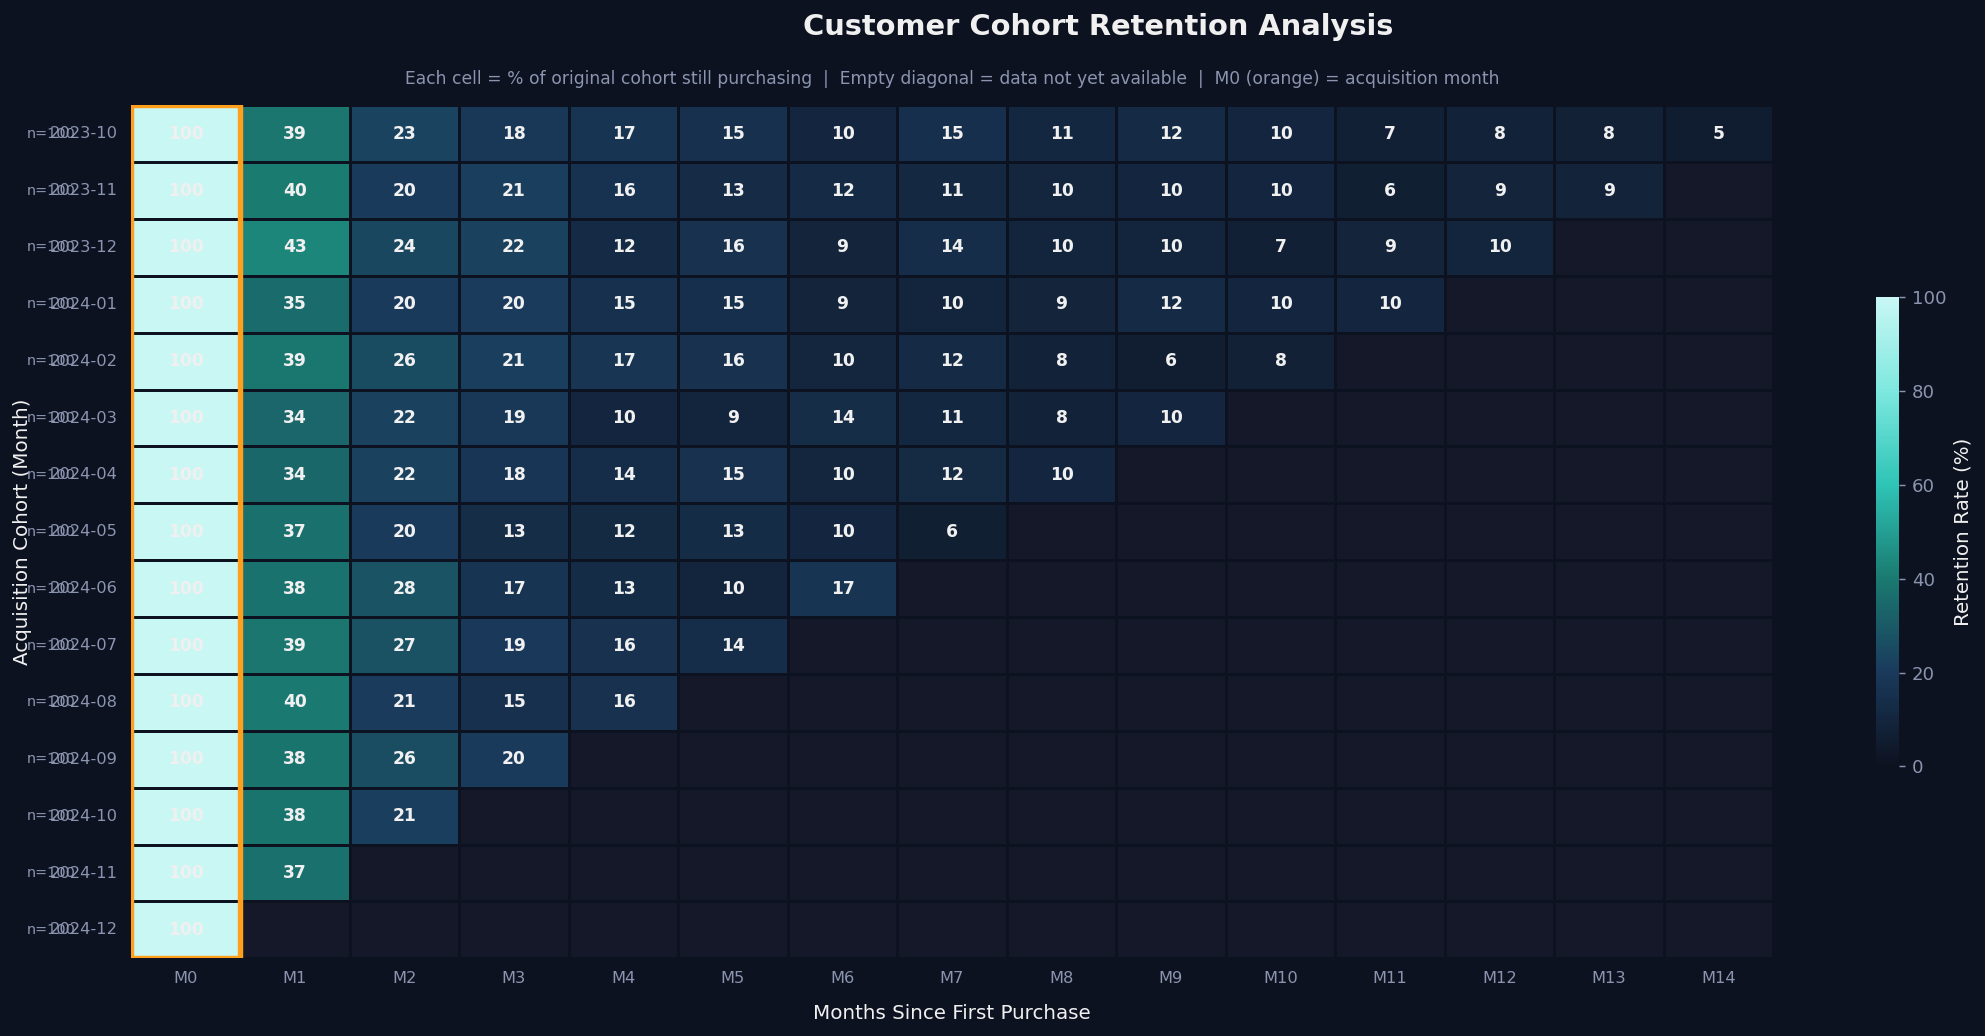

In [14]:
fig, ax = plt.subplots(figsize=(17, 8))
fig.suptitle('Customer Cohort Retention Analysis', fontsize=16, fontweight='bold', color=WHITE, y=0.99)

mask = pivot_retention.isnull()
sns.heatmap(
    pivot_retention, ax=ax, cmap=cm_teal, mask=mask,
    annot=True, fmt='.0f',
    annot_kws={'size': 9.5, 'weight': 'bold', 'color': WHITE},
    linewidths=0.6, linecolor=BG,
    cbar_kws={'label': 'Retention Rate (%)', 'shrink': 0.55},
    vmin=0, vmax=100)

# Cohort size labels
for i, (month, size) in enumerate(cohort_sizes.items()):
    ax.text(-0.5, i + 0.5, f'n={int(size)}',
            ha='right', va='center', fontsize=8, color=GREY, transform=ax.transData)

# Highlight M0 column
ax.add_patch(plt.Rectangle((0, 0), 1, len(pivot_retention),
             fill=False, edgecolor=ORANGE, lw=3, zorder=5))

ax.set_title(
    'Each cell = % of original cohort still purchasing  |  Empty diagonal = data not yet available  |  M0 (orange) = acquisition month',
    fontsize=9.5, color=GREY, pad=12)
ax.set_xlabel('Months Since First Purchase', fontsize=11, labelpad=10)
ax.set_ylabel('Acquisition Cohort (Month)', fontsize=11, labelpad=10)
ax.set_xticklabels([f'M{int(c)}' for c in pivot_retention.columns], fontsize=9)
ax.set_yticklabels(pivot_retention.index, fontsize=9, rotation=0)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
save(fig, '1_cohort_retention_heatmap.png')
plt.show()

### Reading the Heatmap

**The M0 to M1 drop** is the biggest single transition in every cohort — this is normal in e-commerce. The question is how large that drop is and whether it is improving.

**Cohorts that retain well at M1 tend to retain well at M6.** The relative ranking of cohorts tends to be consistent through time.

**Small cohorts (n < 50)** should be interpreted with caution — small denominator changes swing the percentage significantly.

---
## Section 9  Retention Curves

Line charts let us compare the *shape* of retention across cohorts. The left panel shows all cohorts overlaid — useful for spotting outliers. The right panel shows the average with a standard deviation band.

  Saved: 2_retention_curves.png


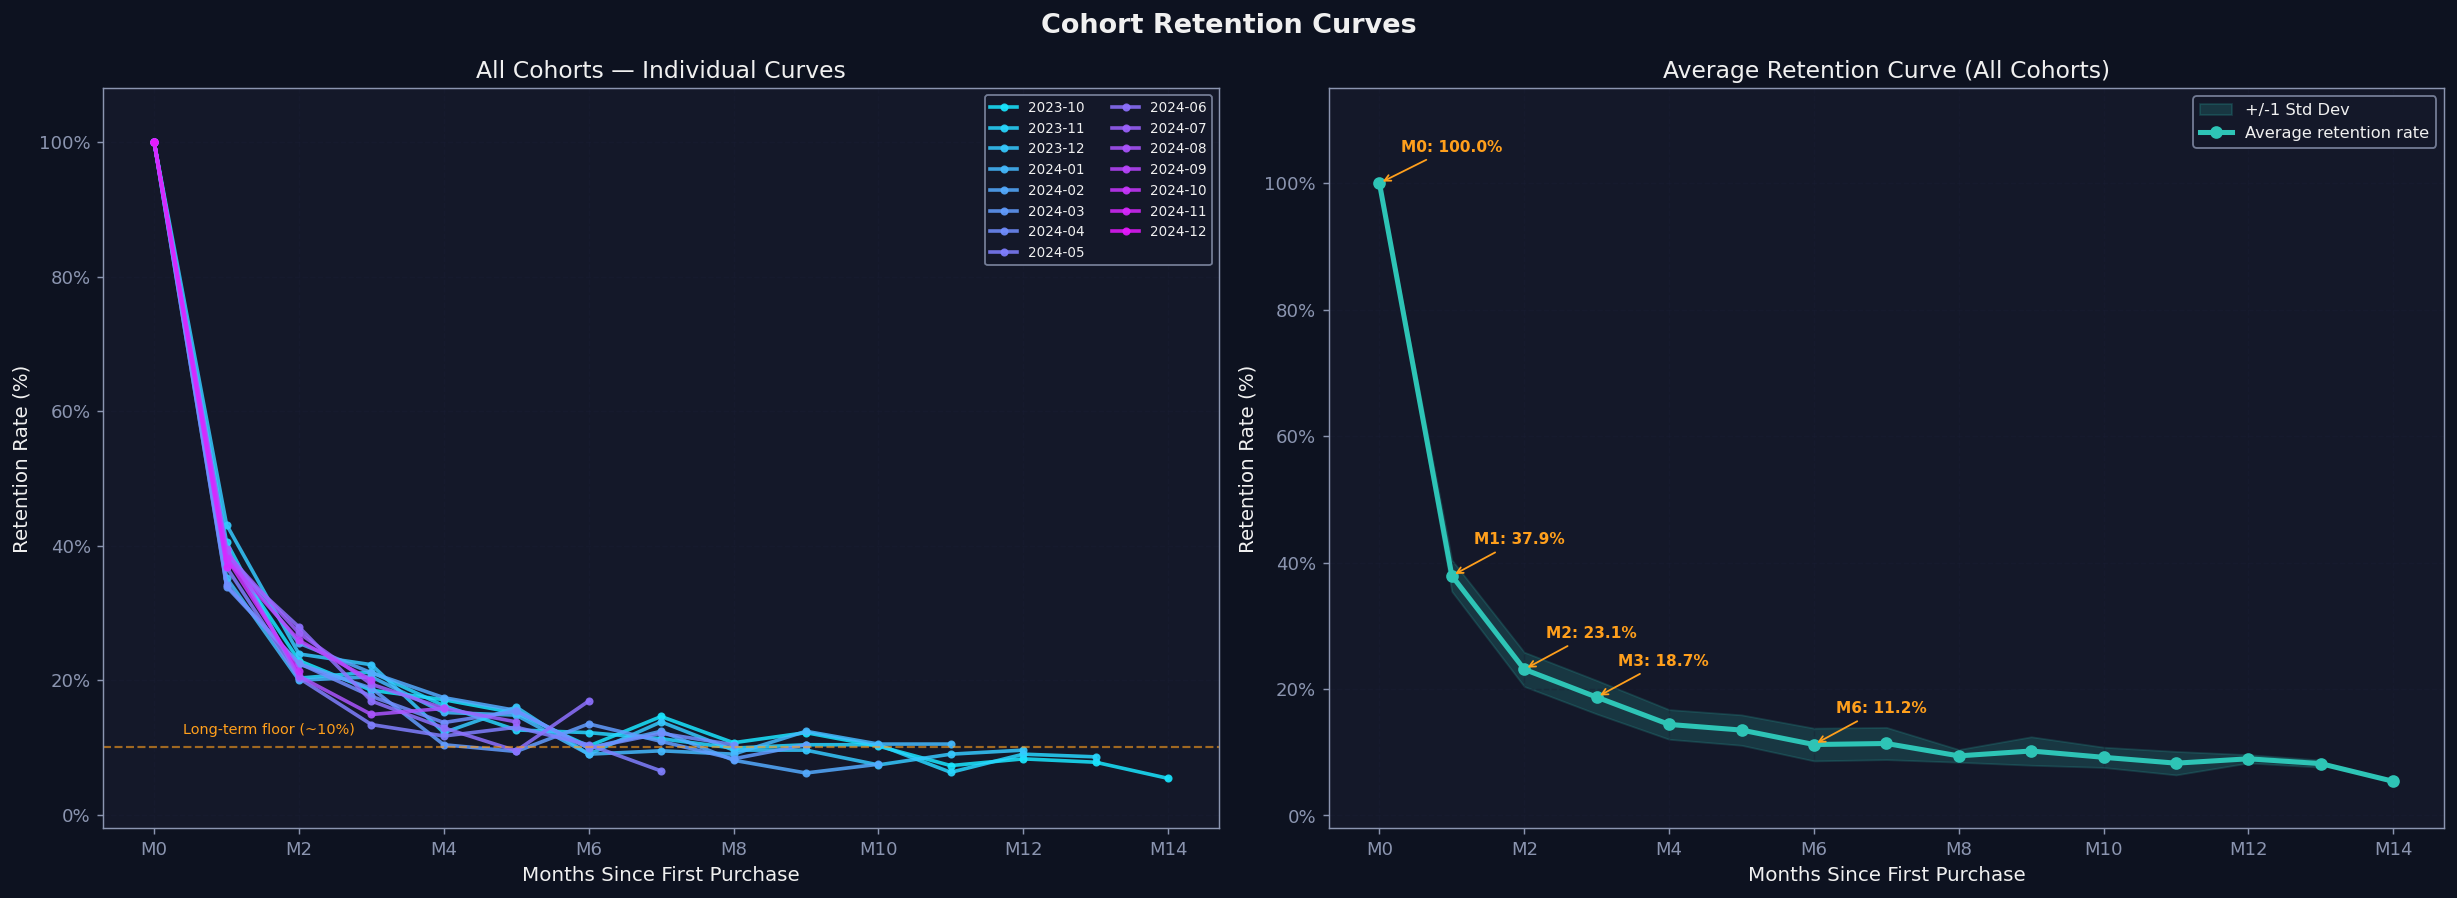

Average retention by month:
  M 0: 100.0%
  M 1: 37.9%
  M 2: 23.1%
  M 3: 18.7%
  M 6: 11.2%
  M 9: 10.2%
  M12: 9.0%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(19, 7))
fig.suptitle('Cohort Retention Curves', fontsize=15, fontweight='bold', color=WHITE)

palette = plt.cm.cool(np.linspace(0.1, 0.9, len(pivot_retention)))

# All cohort curves
ax = axes[0]
for i, (cohort, row) in enumerate(pivot_retention.iterrows()):
    v = row.dropna()
    ax.plot(v.index.astype(int), v.values, color=palette[i],
            linewidth=2, alpha=0.85, marker='o', markersize=3.5, label=cohort)
ax.set_title('All Cohorts — Individual Curves')
ax.set_xlabel('Months Since First Purchase'); ax.set_ylabel('Retention Rate (%)')
ax.set_ylim(-2, 108)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'M{int(x)}'))
ax.axhline(10, color=ORANGE, linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(0.4, 12, 'Long-term floor (~10%)', color=ORANGE, fontsize=8)
ax.legend(fontsize=7.5, loc='upper right', ncol=2)
ax.grid(True)

# Average curve with confidence band
ax2 = axes[1]
avg_ret = pivot_retention.mean()
std_ret = pivot_retention.std()
months  = avg_ret.index.astype(int)

ax2.fill_between(months, (avg_ret-std_ret).clip(0,100), (avg_ret+std_ret).clip(0,100),
                 alpha=0.18, color=TEAL, label='+/-1 Std Dev')
ax2.plot(months, avg_ret.values, color=TEAL, linewidth=2.8,
         marker='o', markersize=6, label='Average retention rate')

for m_idx in [0, 1, 2, 3, 6]:
    if m_idx in avg_ret.index:
        val = avg_ret[m_idx]
        ax2.annotate(f'M{m_idx}: {val:.1f}%', xy=(m_idx, val),
                     xytext=(m_idx+0.3, val+5), fontsize=8.5, color=ORANGE, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))

ax2.set_title('Average Retention Curve (All Cohorts)')
ax2.set_xlabel('Months Since First Purchase'); ax2.set_ylabel('Retention Rate (%)')
ax2.set_ylim(-2, 115)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'M{int(x)}'))
ax2.legend(fontsize=9); ax2.grid(True)

plt.tight_layout()
save(fig, '2_retention_curves.png')
plt.show()

print('Average retention by month:')
for m in [0,1,2,3,6,9,12]:
    if m in avg_ret.index:
        print(f'  M{m:>2}: {avg_ret[m]:.1f}%')

---
## Section 10  Revenue Heatmap

The retention heatmap tells you whether customers come back. The revenue heatmap tells you **how much they spend when they do**.

A common pattern in e-commerce: retained customers spend *more* per order in later months than at acquisition. They know the brand, trust the quality and are buying with more confidence. This matters for lifetime value calculations.

  Saved: 3_revenue_heatmap.png


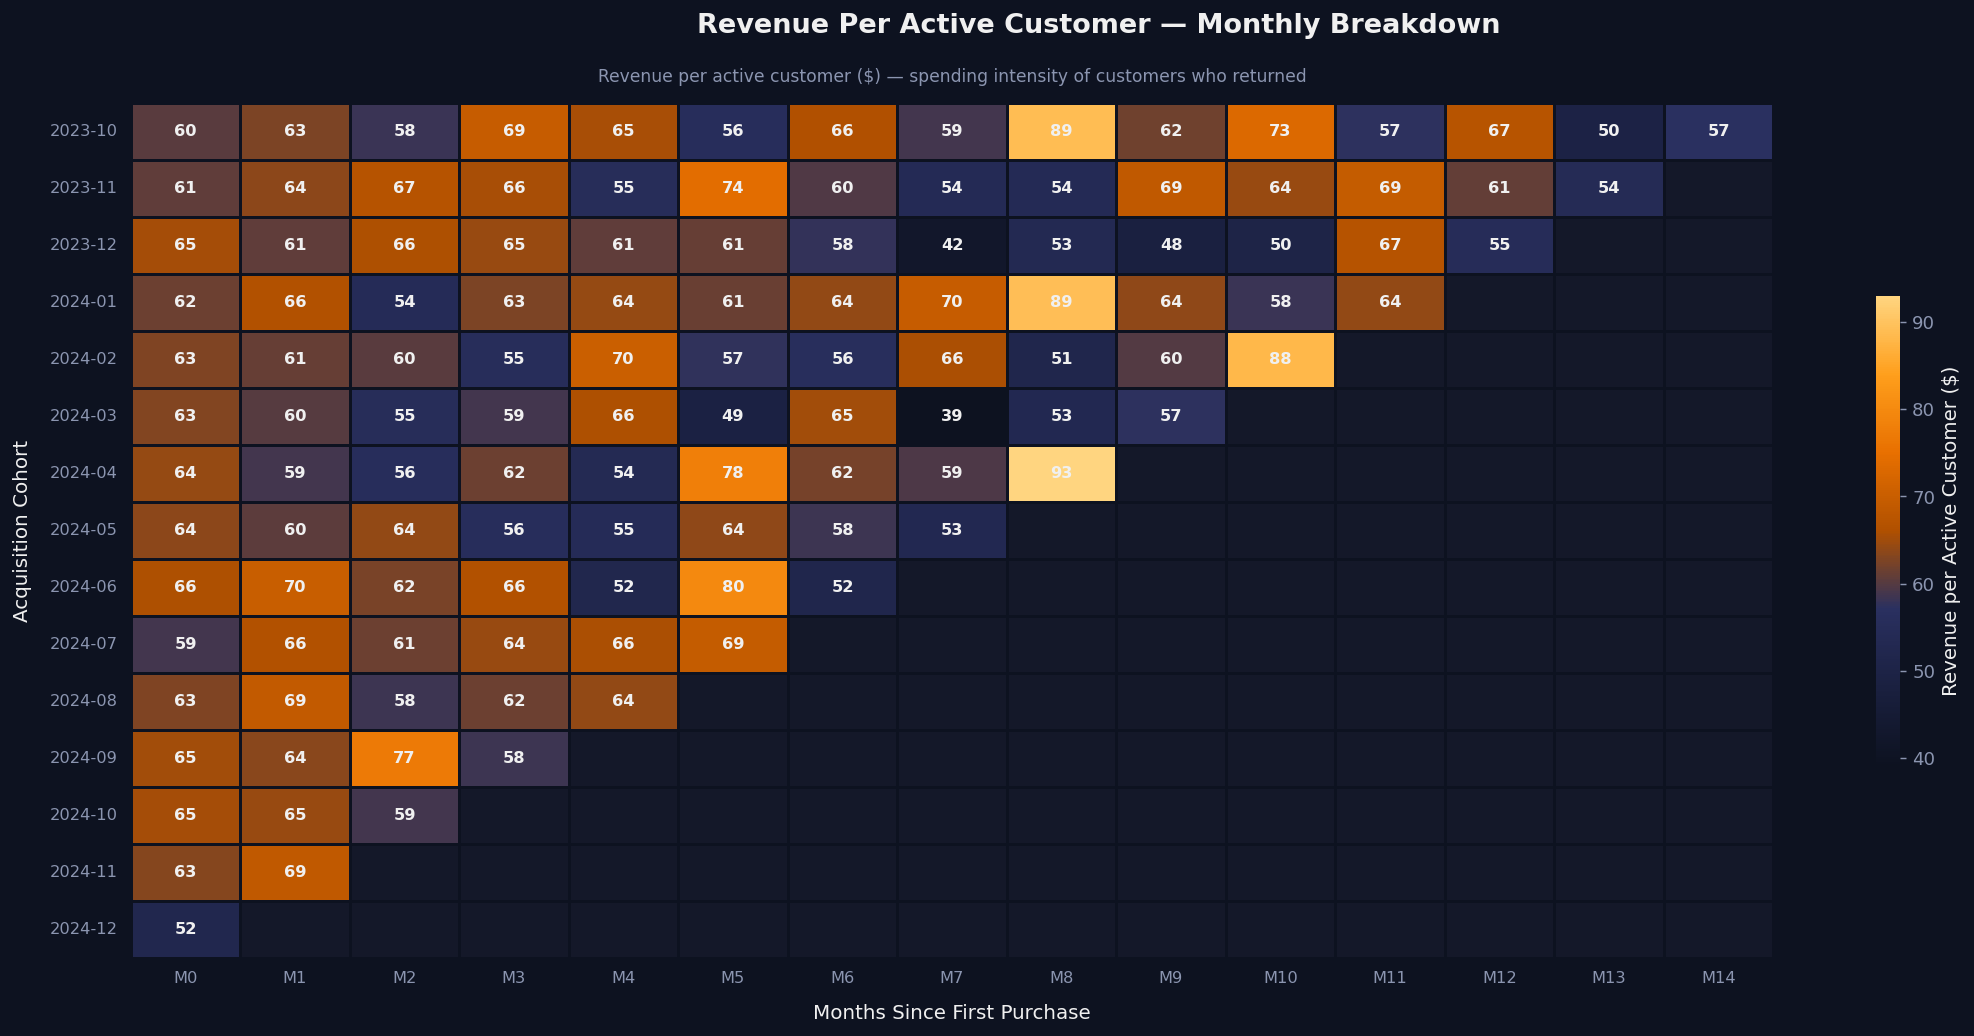

In [16]:
fig, ax = plt.subplots(figsize=(17, 8))
fig.suptitle('Revenue Per Active Customer — Monthly Breakdown', fontsize=15, fontweight='bold', color=WHITE, y=0.99)

mask_rev = pivot_revenue.isnull()
sns.heatmap(
    pivot_revenue, ax=ax, cmap=cm_orange, mask=mask_rev,
    annot=True, fmt='.0f',
    annot_kws={'size': 9, 'weight': 'bold', 'color': WHITE},
    linewidths=0.6, linecolor=BG,
    cbar_kws={'label': 'Revenue per Active Customer ($)', 'shrink': 0.55})

ax.set_title(
    'Revenue per active customer ($) — spending intensity of customers who returned',
    fontsize=9.5, color=GREY, pad=12)
ax.set_xlabel('Months Since First Purchase', fontsize=11, labelpad=10)
ax.set_ylabel('Acquisition Cohort', fontsize=11, labelpad=10)
ax.set_xticklabels([f'M{int(c)}' for c in pivot_revenue.columns], fontsize=9)
ax.set_yticklabels(pivot_revenue.index, fontsize=9, rotation=0)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
save(fig, '3_revenue_heatmap.png')
plt.show()

---
## Section 11  Cohort Size & Retention Trend

Two questions in one chart:
1. Are we acquiring more or fewer customers each month?
2. Is retention improving or declining over time?

If M1 retention is trending downward while acquisition is increasing, the business is masking a retention problem with spending.

  Saved: 4_cohort_size_retention_trend.png


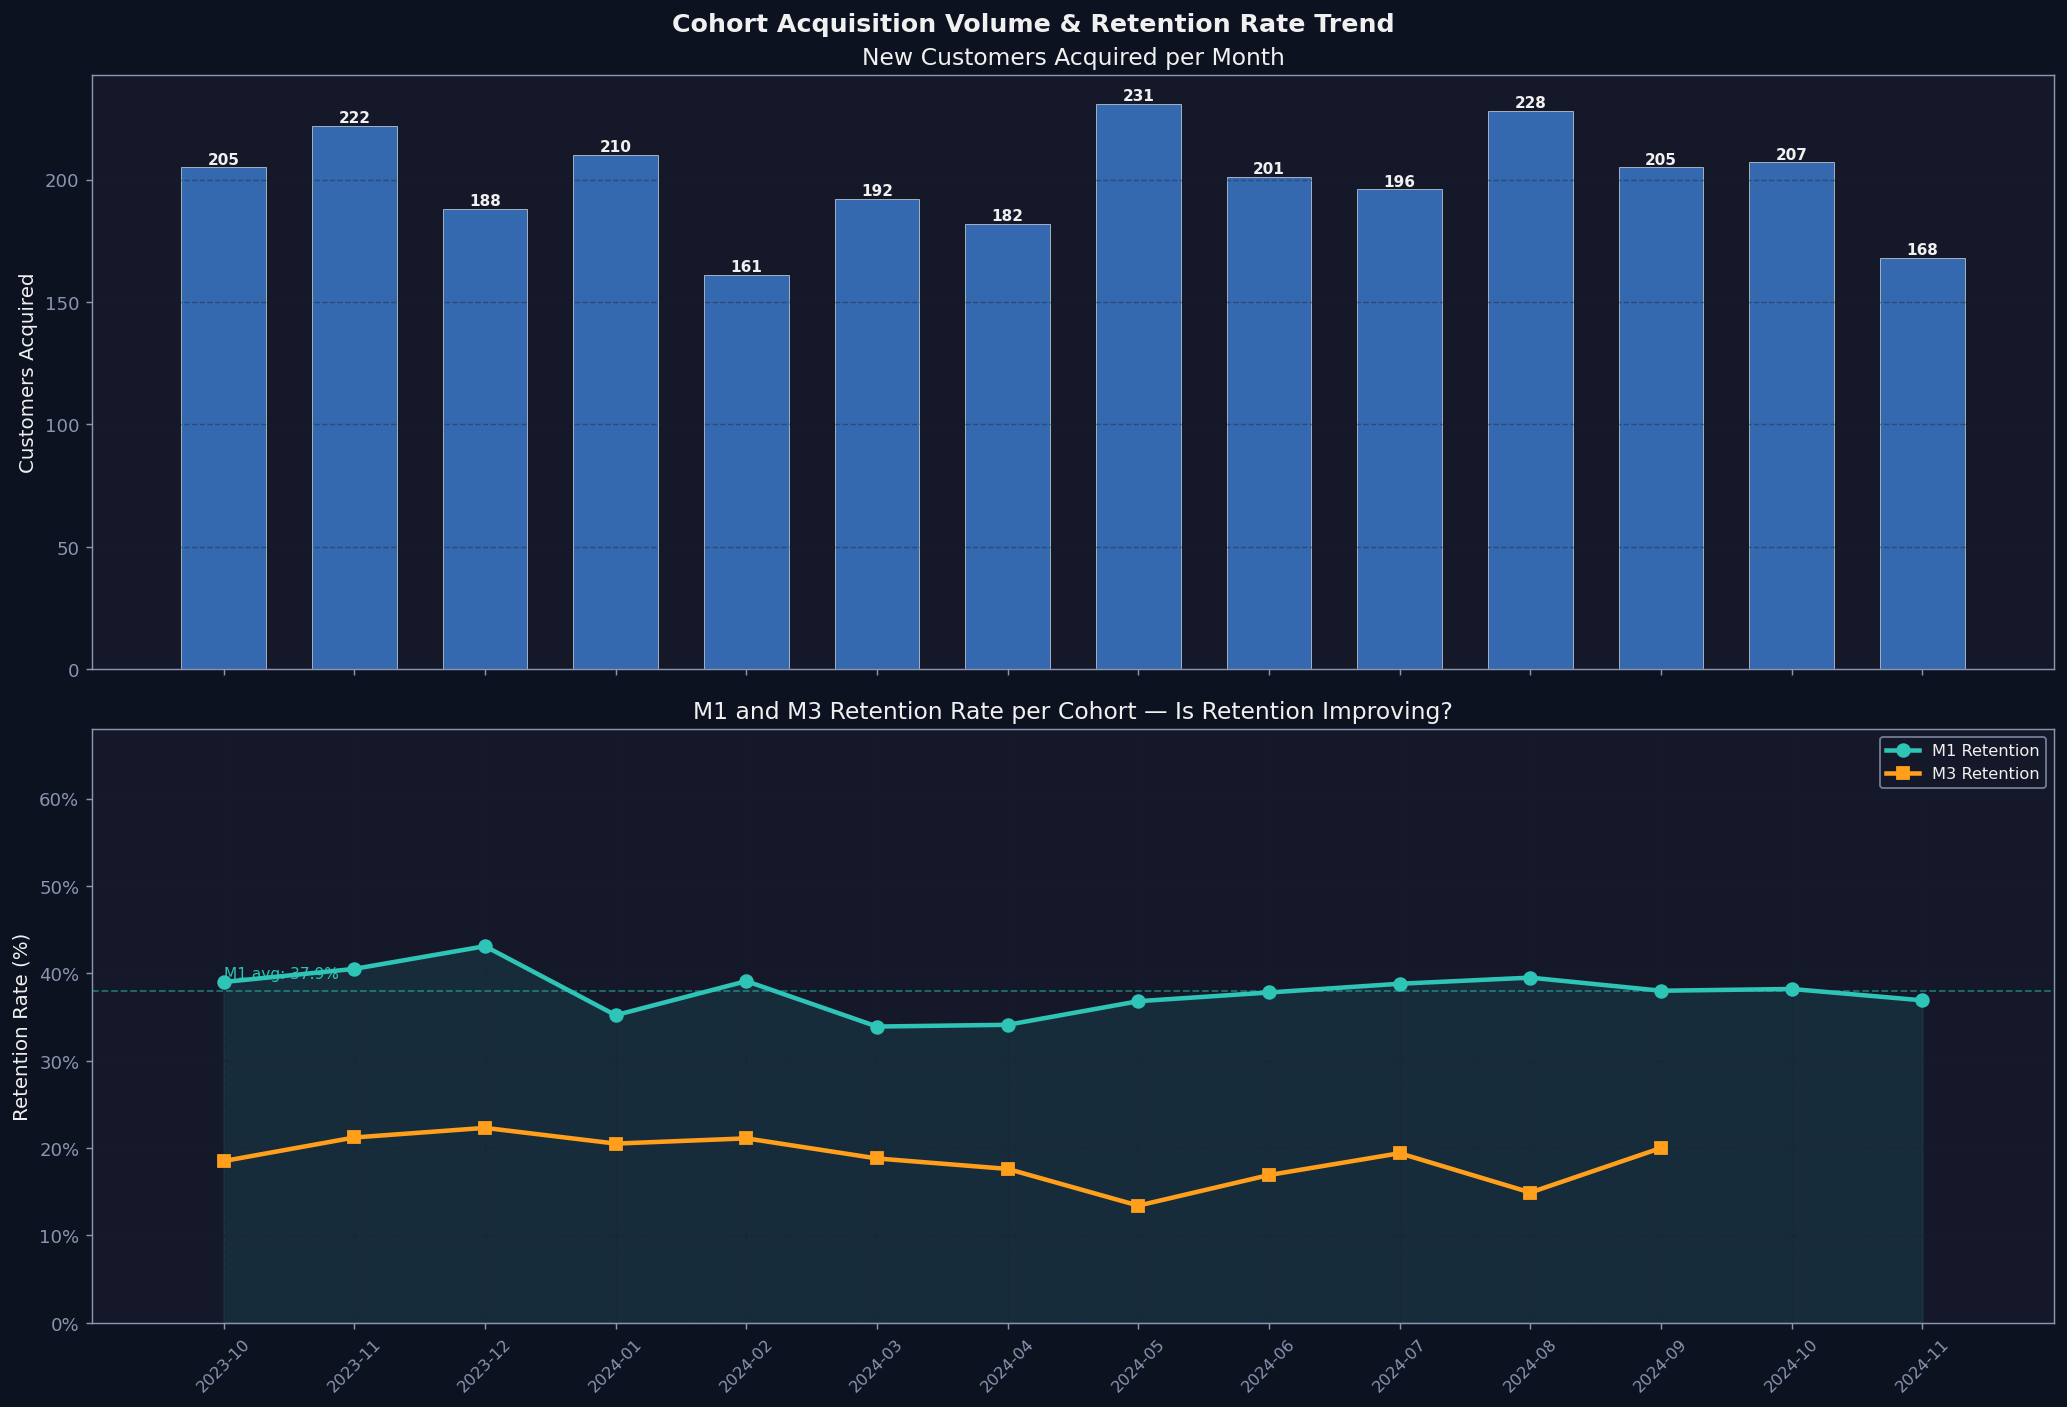

In [17]:
t_m0 = retention_df[retention_df['cohort_index']==0][['cohort_month','cohort_size']].copy()
t_m1 = retention_df[retention_df['cohort_index']==1][['cohort_month','retention_rate_pct']].rename(columns={'retention_rate_pct':'m1'})
t_m3 = retention_df[retention_df['cohort_index']==3][['cohort_month','retention_rate_pct']].rename(columns={'retention_rate_pct':'m3'})
td = t_m0.merge(t_m1, on='cohort_month', how='left').merge(t_m3, on='cohort_month', how='left')
td = td[(td['cohort_month']>='2023-10') & (td['cohort_size']>=30)]

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Cohort Acquisition Volume & Retention Rate Trend', fontsize=14, fontweight='bold', color=WHITE)

# Top: acquisition volume
ax = axes[0]
bars = ax.bar(td['cohort_month'], td['cohort_size'],
              color=BLUE, edgecolor=WHITE, linewidth=0.4, alpha=0.85, width=0.65)
for bar, val in zip(bars, td['cohort_size']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{int(val)}', ha='center', color=WHITE, fontsize=8.5, fontweight='bold')
ax.set_title('New Customers Acquired per Month')
ax.set_ylabel('Customers Acquired'); ax.grid(axis='y')

# Bottom: M1 and M3 trend
ax2 = axes[1]
v1 = td.dropna(subset=['m1']); v3 = td.dropna(subset=['m3'])
ax2.plot(v1['cohort_month'], v1['m1'], color=TEAL, linewidth=2.5, marker='o', markersize=7, label='M1 Retention')
ax2.plot(v3['cohort_month'], v3['m3'], color=ORANGE, linewidth=2.5, marker='s', markersize=7, label='M3 Retention')
ax2.fill_between(v1['cohort_month'], v1['m1'], alpha=0.12, color=TEAL)
ax2.axhline(v1['m1'].mean(), color=TEAL, linestyle='--', linewidth=1, alpha=0.5)
ax2.text(v1['cohort_month'].iloc[0], v1['m1'].mean()+1.5,
         f'M1 avg: {v1["m1"].mean():.1f}%', color=TEAL, fontsize=8.5)
ax2.set_title('M1 and M3 Retention Rate per Cohort — Is Retention Improving?')
ax2.set_ylabel('Retention Rate (%)'); ax2.set_ylim(0, 68)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax2.legend(fontsize=9); ax2.grid(True); ax2.tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
save(fig, '4_cohort_size_retention_trend.png')
plt.show()

---
## Section 12  Cumulative Revenue by Cohort

This chart reframes the question from "who is coming back?" to "how much is each cohort worth over time?" Each line is one acquisition cohort — steeper lines represent cohorts with higher long-term revenue. This is the chart to use in a financial or investor context.

  Saved: 5_cumulative_revenue.png


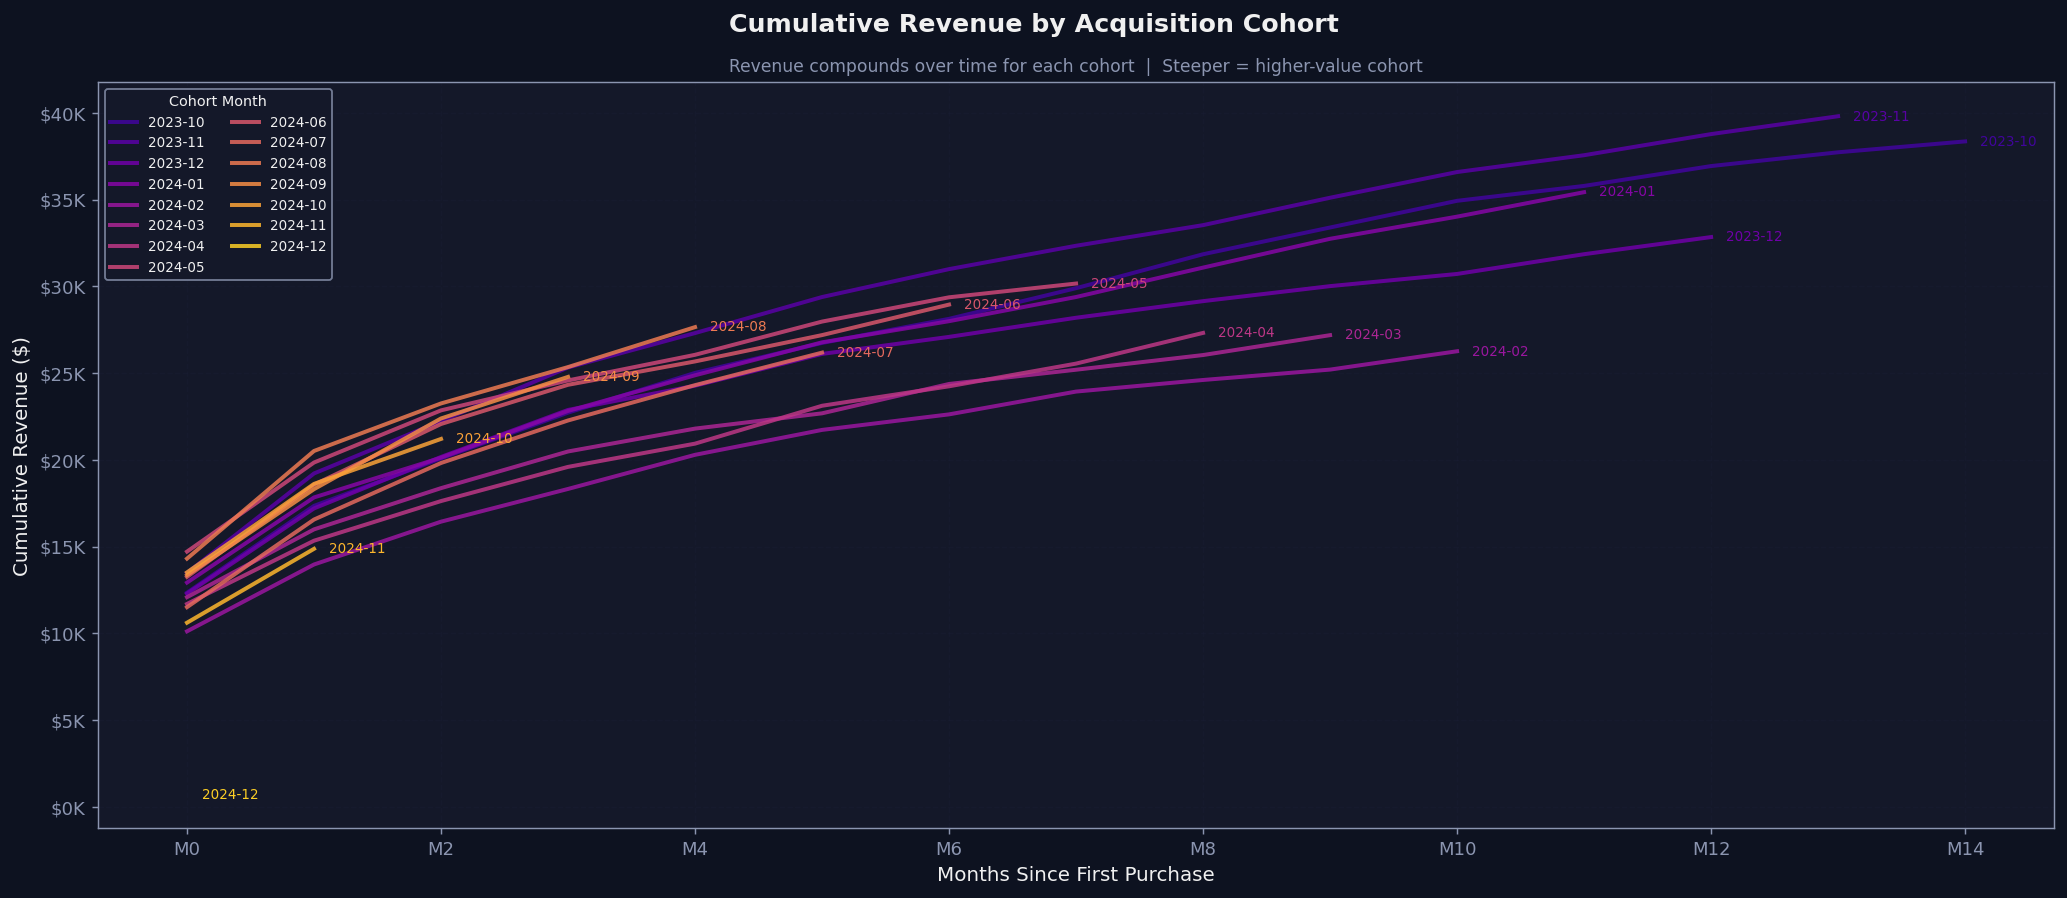

In [18]:
cumrev = pivot_rev_total.cumsum(axis=1)

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('Cumulative Revenue by Acquisition Cohort', fontsize=14, fontweight='bold', color=WHITE)

palette_p = plt.cm.plasma(np.linspace(0.1, 0.9, len(cumrev)))
for i, (cohort, row) in enumerate(cumrev.iterrows()):
    v = row.dropna()
    ax.plot(v.index.astype(int), v.values, color=palette_p[i],
            linewidth=2.2, alpha=0.85, label=cohort)
    if len(v) > 0:
        ax.text(v.index[-1]+0.12, v.iloc[-1], cohort, fontsize=7.5,
                color=palette_p[i], va='center')

ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cumulative Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'M{int(x)}'))
ax.set_title('Revenue compounds over time for each cohort  |  Steeper = higher-value cohort', fontsize=9.5, color=GREY)
ax.legend(fontsize=7.5, loc='upper left', ncol=2, title='Cohort Month', title_fontsize=8)
ax.grid(True)

plt.tight_layout()
save(fig, '5_cumulative_revenue.png')
plt.show()

---
## Section 13  Executive Dashboard

All key metrics on one page. This is what you would present in a leadership meeting — the numbers that matter, without noise.

  Saved: 6_executive_dashboard.png


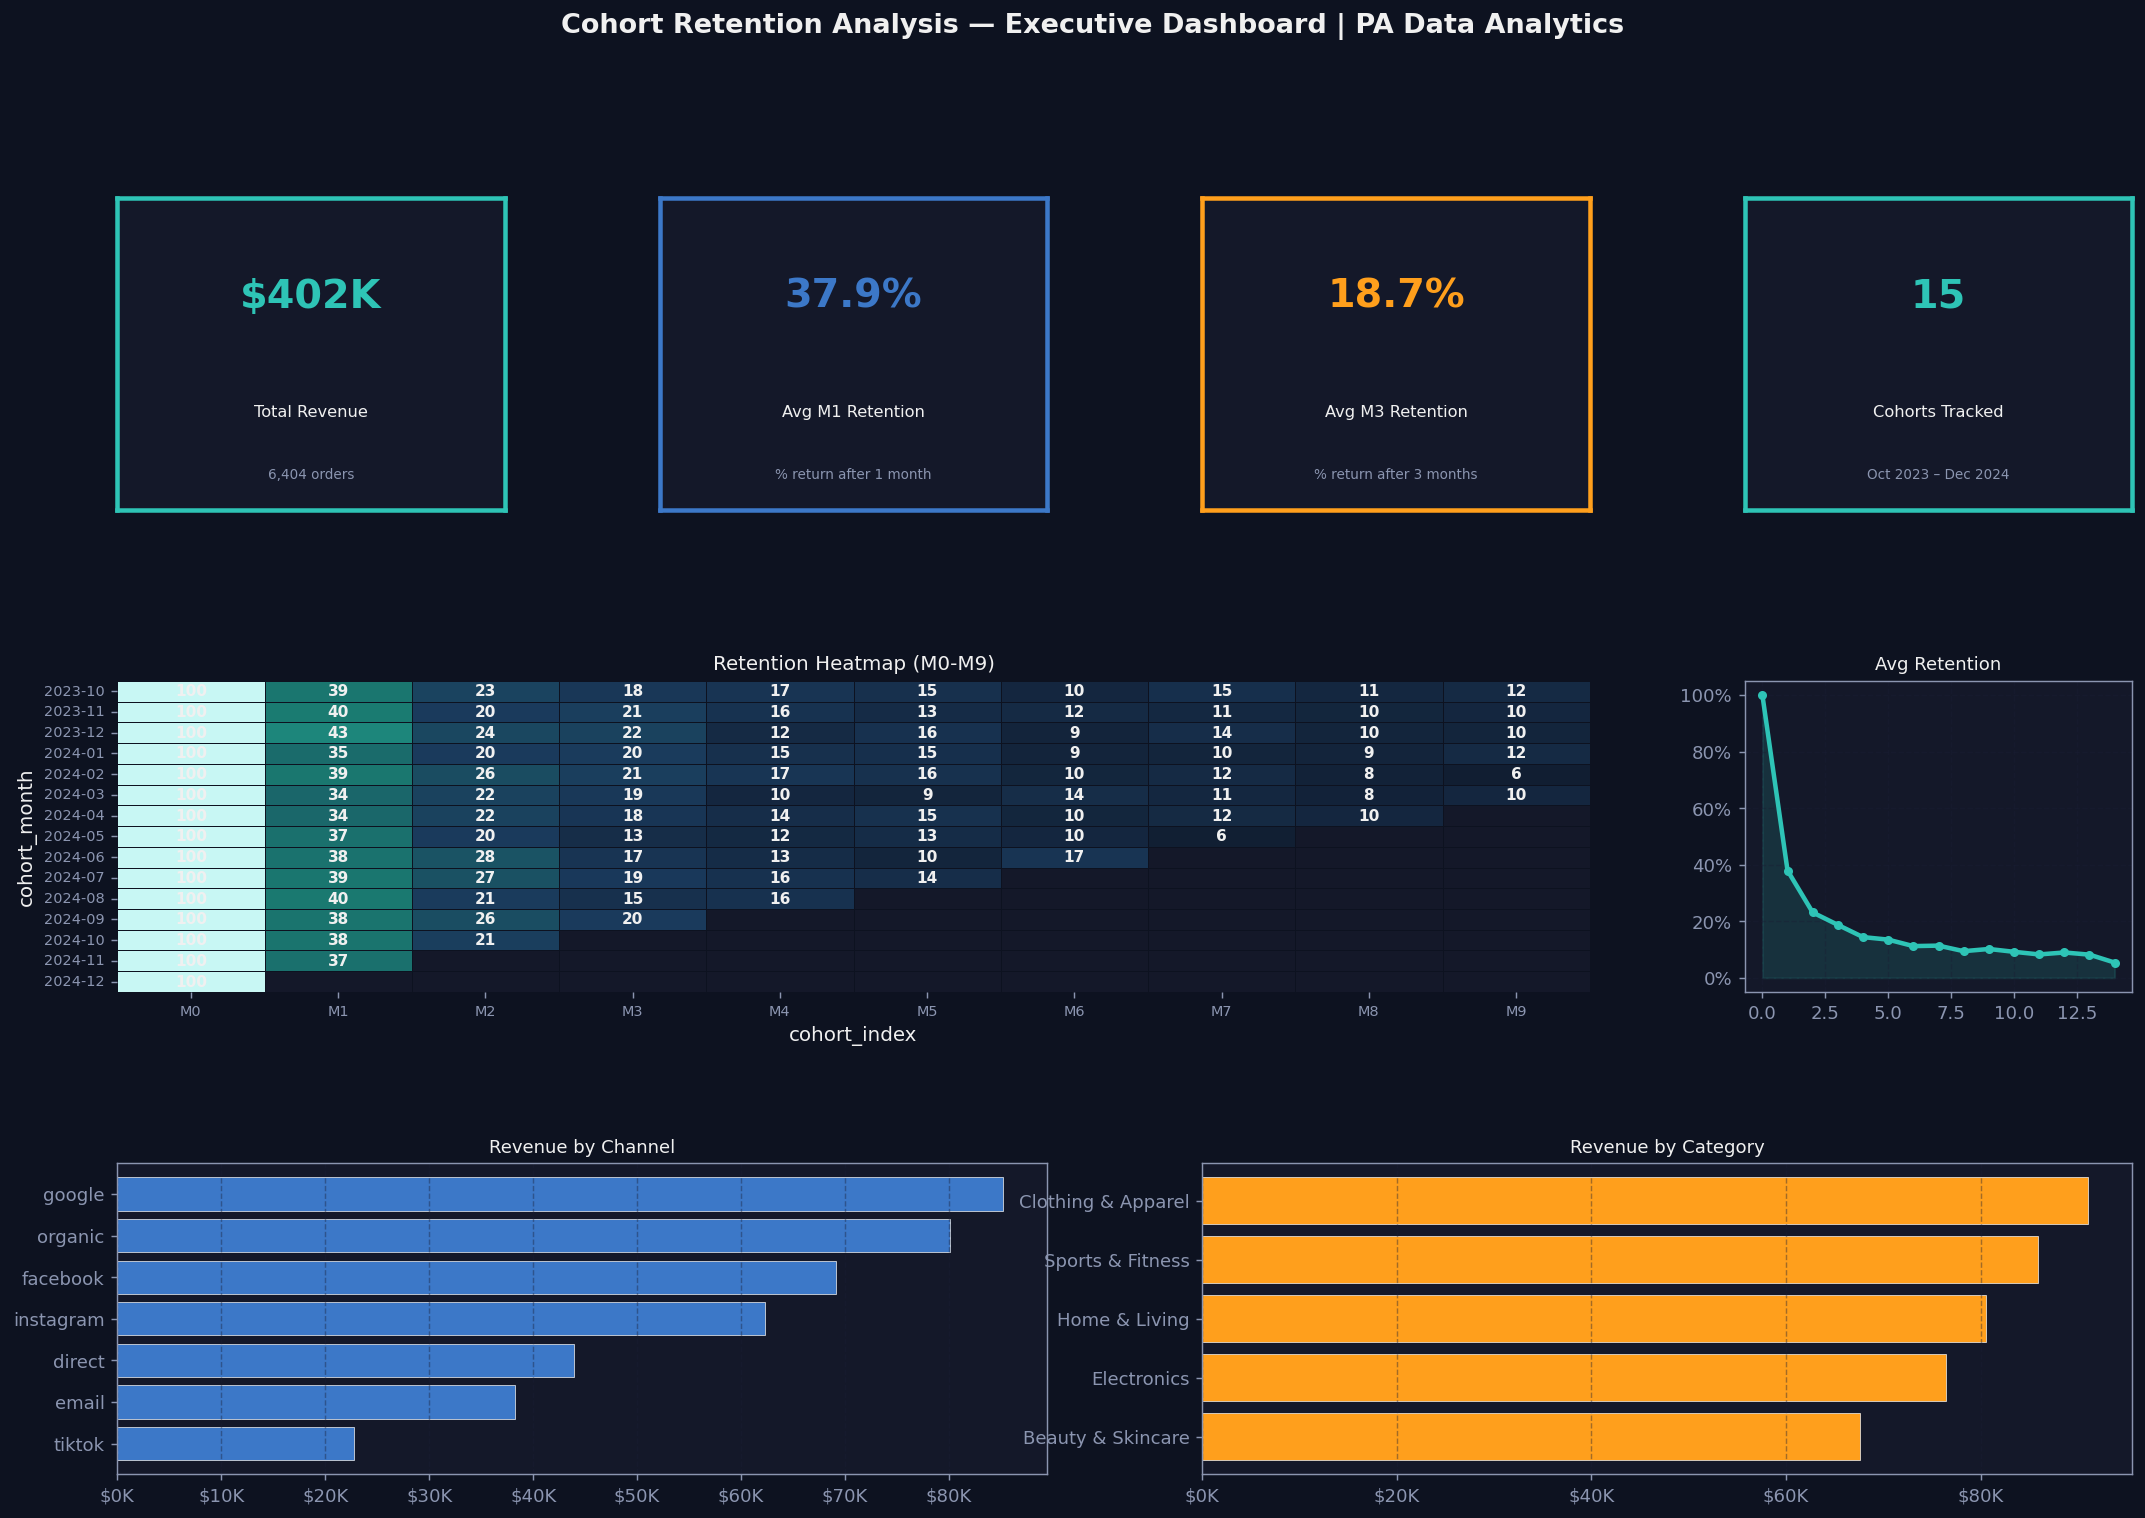

In [19]:
fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

def kpi_box(ax, label, value, sub='', color=TEAL):
    ax.set_facecolor(DARK)
    for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(2.5)
    ax.text(0.5, 0.65, value, transform=ax.transAxes, ha='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.30, label,  transform=ax.transAxes, ha='center', fontsize=9, color=WHITE)
    if sub: ax.text(0.5, 0.10, sub, transform=ax.transAxes, ha='center', fontsize=7.5, color=GREY)
    ax.set_xticks([]); ax.set_yticks([])

m1a = pivot_retention[1].mean() if 1 in pivot_retention.columns else 0
m3a = pivot_retention[3].mean() if 3 in pivot_retention.columns else 0

for i, (lbl, val, sub, col) in enumerate([
    ('Total Revenue',     f'${df_clean["total_price"].sum()/1e3:.0f}K', f'{len(df_clean):,} orders', TEAL),
    ('Avg M1 Retention',  f'{m1a:.1f}%',   '% return after 1 month',    BLUE),
    ('Avg M3 Retention',  f'{m3a:.1f}%',   '% return after 3 months',   ORANGE),
    ('Cohorts Tracked',   f'{len(pivot_retention)}', 'Oct 2023 – Dec 2024', TEAL),
]):
    ax = fig.add_subplot(gs[0, i])
    kpi_box(ax, lbl, val, sub, col)

cols_show = [c for c in pivot_retention.columns if c <= 9]
ax_hm = fig.add_subplot(gs[1, :3])
ax_hm.set_facecolor(DARK)
sns.heatmap(pivot_retention[cols_show], ax=ax_hm, cmap=cm_teal,
    annot=True, fmt='.0f', annot_kws={'size':8.5,'weight':'bold','color':WHITE},
    linewidths=0.4, linecolor=BG, cbar=False, vmin=0, vmax=100,
    mask=pivot_retention[cols_show].isnull())
ax_hm.set_title('Retention Heatmap (M0-M9)', color=WHITE, fontsize=11)
ax_hm.set_xticklabels([f'M{int(c)}' for c in cols_show], fontsize=8)
ax_hm.set_yticklabels(pivot_retention.index, fontsize=8, rotation=0)

ax_c = fig.add_subplot(gs[1, 3])
ax_c.set_facecolor(DARK)
avg2 = pivot_retention.mean().dropna()
ax_c.plot(avg2.index.astype(int), avg2.values, color=TEAL, linewidth=2.5, marker='o', markersize=4)
ax_c.fill_between(avg2.index.astype(int), avg2.values, alpha=0.15, color=TEAL)
ax_c.set_title('Avg Retention', color=WHITE, fontsize=10)
ax_c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%')); ax_c.grid(True)

ax_ch = fig.add_subplot(gs[2, :2]); ax_ch.set_facecolor(DARK)
ch2 = channel_summary.sort_values('total_revenue', ascending=True)
ax_ch.barh(ch2['channel'], ch2['total_revenue'], color=BLUE, edgecolor=WHITE, linewidth=0.4)
ax_ch.set_title('Revenue by Channel', color=WHITE, fontsize=10)
ax_ch.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K')); ax_ch.grid(axis='x')

ax_cat = fig.add_subplot(gs[2, 2:]); ax_cat.set_facecolor(DARK)
cat2 = df_clean.groupby('product_category')['total_price'].sum().sort_values()
ax_cat.barh(cat2.index, cat2.values, color=ORANGE, edgecolor=WHITE, linewidth=0.4)
ax_cat.set_title('Revenue by Category', color=WHITE, fontsize=10)
ax_cat.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K')); ax_cat.grid(axis='x')

fig.suptitle('Cohort Retention Analysis — Executive Dashboard | PA Data Analytics',
             fontsize=15, fontweight='bold', color=WHITE, y=0.99)
save(fig, '6_executive_dashboard.png')
plt.show()

---
## Section 14  Key Findings

In [20]:
m1v  = pivot_retention[1].mean()  if 1  in pivot_retention.columns else 0
m2v  = pivot_retention[2].mean()  if 2  in pivot_retention.columns else 0
m3v  = pivot_retention[3].mean()  if 3  in pivot_retention.columns else 0
m6v  = pivot_retention[6].mean()  if 6  in pivot_retention.columns else 0
m12v = pivot_retention[12].mean() if 12 in pivot_retention.columns else 0

print("RETENTION RATES (average across all cohorts)")
print(f"  M0   : 100.0%  <- baseline")
print(f"  M1   : {m1v:.1f}%  <- largest single drop  ({100-m1v:.1f}pp lost)")
print(f"  M2   : {m2v:.1f}%")
print(f"  M3   : {m3v:.1f}%  <- curve begins to level off")
print(f"  M6   : {m6v:.1f}%  <- long-term retention floor")
print(f"  M12  : {m12v:.1f}%  <- loyal customer base")
print()
print("DROP-OFF ANALYSIS")
print(f"  M0-M1 drop : -{100-m1v:.1f}pp  <- most critical intervention point")
print(f"  M1-M2 drop : -{m1v-m2v:.1f}pp")
print(f"  M2-M3 drop : -{m2v-m3v:.1f}pp")
print()
print("REVENUE SNAPSHOT")
print(f"  Total revenue    : ${df_clean['total_price'].sum():,.0f}")
print(f"  Total orders     : {len(df_clean):,}")
print(f"  Unique customers : {df_clean['customer_id'].nunique():,}")
print(f"  Overall AOV      : ${df_clean['total_price'].mean():.2f}")
print(f"  Top channel      : {channel_summary.iloc[0]['channel']}  (${channel_summary.iloc[0]['total_revenue']:,.0f})")
print(f"  Top category     : {df_clean.groupby('product_category')['total_price'].sum().idxmax()}")

RETENTION RATES (average across all cohorts)
  M0   : 100.0%  <- baseline
  M1   : 37.9%  <- largest single drop  (62.1pp lost)
  M2   : 23.1%
  M3   : 18.7%  <- curve begins to level off
  M6   : 11.2%  <- long-term retention floor
  M12  : 9.0%  <- loyal customer base

DROP-OFF ANALYSIS
  M0-M1 drop : -62.1pp  <- most critical intervention point
  M1-M2 drop : -14.8pp
  M2-M3 drop : -4.4pp

REVENUE SNAPSHOT
  Total revenue    : $401,672
  Total orders     : 6,404
  Unique customers : 2,810
  Overall AOV      : $62.72
  Top channel      : google  ($85,191)
  Top category     : Clothing & Apparel


---
## Section 15  Business Recommendations

---

### Priority 1  Fix the M0 to M1 Problem First

**The finding:** Only ~38% of customers come back after their first purchase.

**Why this is the highest-leverage intervention:** Improving M1 from 38% to 43% compounds through every month of every cohort going forward. It is the single biggest lever in the entire analysis.

**What to do:**
- Launch a post-purchase email sequence starting 7 days after the first order. The goal is one thing only: the second purchase.
- Make it product-relevant. If someone bought from Clothing, show them complementary items — not a generic newsletter.
- Offer a 10–15% incentive on the second purchase. The goal is reducing friction, not giving revenue away permanently.
- Test Day 5 versus Day 10 sends — the optimal window varies by category and average delivery time.

---

### Priority 2  Measure Channel Retention, Not Just Channel Revenue

**The finding:** Google is the top revenue channel overall. But top acquisition revenue is not the same as top retention-weighted revenue.

**What to do:**
- Build the retention heatmap segmented by acquisition channel. Compare M1 and M3 rates for customers acquired via Google, Facebook, Email and Organic separately.
- If email-acquired customers retain at 45% M1 and Google-acquired at 35%, the cost-per-retained-customer calculation shifts significantly — even if Google drives more total volume.
- Allocate budget based on cost per retained customer, not cost per first purchase.

---

### Priority 3  Re-engage Customers Between M2 and M3

**The finding:** The M1 to M3 drop is smaller than M0 to M1 but still meaningful. Customers who came back for a second purchase are still leaving before becoming habitual buyers.

**What to do:**
- Customers who have placed exactly 2 orders but not ordered again within 45 days should receive a specific re-engagement campaign — different in tone from the M1 sequence because these customers already know and trust the brand.
- A loyalty programme that activates after the second purchase has its highest impact here. You are converting a repeat buyer into a habitual one.

---

### Priority 4  Protect the Long-Term Loyal Customers (~M6+)

**The finding:** Customers who reach M6 are still purchasing at around 11%. These are high-LTV customers.

**What to do:**
- Identify them in CRM by filtering for customers with a cohort index of 6+ who are still active.
- Exclusive early access, personalised recommendations, VIP status — these cost little and signal to a loyal customer that the brand recognises them.
- Once a 6-month customer churns, they almost never come back. Protecting this group is significantly cheaper than re-acquiring them.

---

### Priority 5  Track Two Numbers Monthly

**What to do:**
- Every month, record the M1 retention rate for the most recent cohort and the M3 retention rate for the cohort from three months ago.
- Set a threshold: if M1 drops below 30% for any cohort, review post-purchase communications and any product or service changes in that period.
- The Power BI export in `data/processed/cohort_retention_powerbi.csv` connects directly to Power BI — build this dashboard once and it updates automatically.

---

### Summary

| Priority | Action | Timeframe | Metric to watch |
|---|---|---|---|
| 1 | Post-purchase email sequence (Day 5–10) | Week 1–2 | M1 retention rate |
| 2 | Channel-specific cohort analysis | Month 1 | M1 by channel |
| 3 | Re-engagement for 2-purchase customers | Month 1–2 | M2–M3 drop |
| 4 | VIP programme for M6+ customers | Month 2–3 | M6 churn rate |
| 5 | Monthly cohort dashboard in Power BI | Week 2 | M1 trend line |

---
## Section 16  Export Deliverables

In [21]:
retention_df.to_csv(DATA_P / 'cohort_retention_rates.csv', index=False)
pivot_retention.to_csv(DATA_P / 'cohort_pivot_retention.csv')
revenue_by_cohort.to_csv(DATA_P / 'cohort_revenue_summary.csv', index=False)

pb = retention_df.copy()
pb['cohort_label'] = pb.apply(lambda r: f"Cohort {r['cohort_month']} (n={int(r['cohort_size'])})", axis=1)
pb['month_label']  = pb['cohort_index'].apply(lambda x: f'M{int(x)}')
pb.to_csv(DATA_P / 'cohort_retention_powerbi.csv', index=False)

print("Files exported to data/processed/:")
for f in sorted(DATA_P.glob("*.csv")):
    print(f"  {f.name:<44}  {f.stat().st_size/1024:.1f} KB")
print()
print("Visuals saved to visuals/:")
for f in sorted(VISUALS.glob("*.png")):
    print(f"  {f.name:<44}  {f.stat().st_size/1024:.0f} KB")

Files exported to data/processed/:
  cohort_pivot_retention.csv                    0.9 KB
  cohort_retention_powerbi.csv                  5.9 KB
  cohort_retention_rates.csv                    2.8 KB
  cohort_revenue_summary.csv                    0.6 KB

Visuals saved to visuals/:
  0_monthly_overview.png                        223 KB
  0b_channel_category.png                       125 KB
  1_cohort_retention_heatmap.png                175 KB
  2_retention_curves.png                        257 KB
  3_revenue_heatmap.png                         180 KB
  4_channel_category.png                        138 KB
  4_cohort_size_retention_trend.png             167 KB
  5_cohort_size_retention_trend.png             163 KB
  5_cumulative_revenue.png                      231 KB
  6_cumulative_revenue.png                      232 KB
  6_executive_dashboard.png                     246 KB
  7_executive_dashboard.png                     259 KB
